## HateXplain - 4 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification

* **Target 1:** Hate speech againt African
* **Target 2:** Hate speech against Women
* **Target 3:** Hate speech against Jewish
* **Target 4:** Hate speech against Homosexual

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from datasets import load_dataset

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

In [4]:
# Setting a seed for reproducibility
from machinemoo.utils.seed_config import set_np_torch_seed
set_np_torch_seed(42)

In [5]:
import pickle

In [6]:
PREFIX_SAVE_IMAGE = 'images/4_objs'

In [7]:
PREFIX_SAVE_RESULT = '4_objs'

## Dataset and Model

In [8]:
# Get HateXplain Dataset
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)

# Choose BERT model
model_name="bert-base-uncased"

In [9]:
# Use GPU if its available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [10]:
task_config = {
   "African": {"type": "group_hate", "group": "African"},
   "Women": {"type": "group_hate", "group": "Women"},
   "Jewish": {"type": "group_hate", "group": "Jewish"},
   "Homosexual": {"type": "group_hate", "group": "Homosexual"},
}

In [11]:
train_dataloader = pp.get_dataloader(dataset['train'], task_config)

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [12]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 500,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
objectives_names = list(task_config.keys())

# Control optimization output (Default is False):
#   verbose=True -> show optimization progress
#   debug=True   -> show detailed debug information
verbose = False
debug = False

def machine_optimize(method, lb_estimate=0.01):
    w_scalar = NLPScalarization(
        train_dataloader = train_dataloader, 
        device = device, 
        task_names = objectives_names, 
        lower_bound_estimate=lb_estimate
    )
    moopt = moo(w_scalar, verbose=verbose, debug=debug).mo_optimization(method, **opt_params)
    objs = get_objectives(moopt)
    if method == 'mola':
        hypervolume_values = moopt.get_hypervolumes()
    else:
        hypervolume_values = compute_hypervolume_progress(objs)
    if lb_estimate == 'lipschitz':
        method = f'{method}_grad'
    results[method] = {
                    "moopt": moopt,
                    "objectives": objs,
                    "models": get_models(moopt),
                    "hypervolume": hypervolume_values
                }

In [13]:
def plot_frontier(method, color="#d73027"):
    title="Loss Trade-offs in Multi-Group Hate Speech Detection"
    plot_pareto(methods={method: results[method]['objectives']},
                labels=objectives_names, 
                title=title,
                color=color,
                fontsize=20,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}.pdf'
                )

### MOLA

In [14]:
method = 'mola'
machine_optimize(method=method)

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


...

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


<Figure size 1000x700 with 0 Axes>

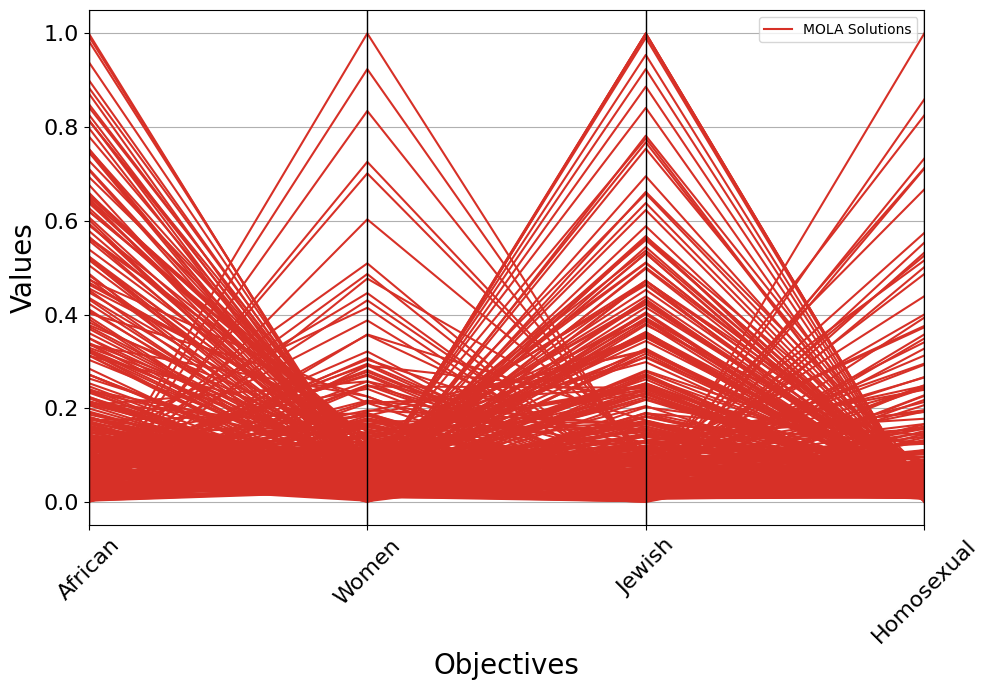

In [15]:
plot_frontier(method, color='#d73027')

In [17]:
import dill

In [18]:
# save results
with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "wb") as f:
    dill.dump(results, f)

### MOLA with gradient

In [19]:
method = 'mola'
machine_optimize(method=method, lb_estimate='lipschitz')

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


...

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


<Figure size 1000x700 with 0 Axes>

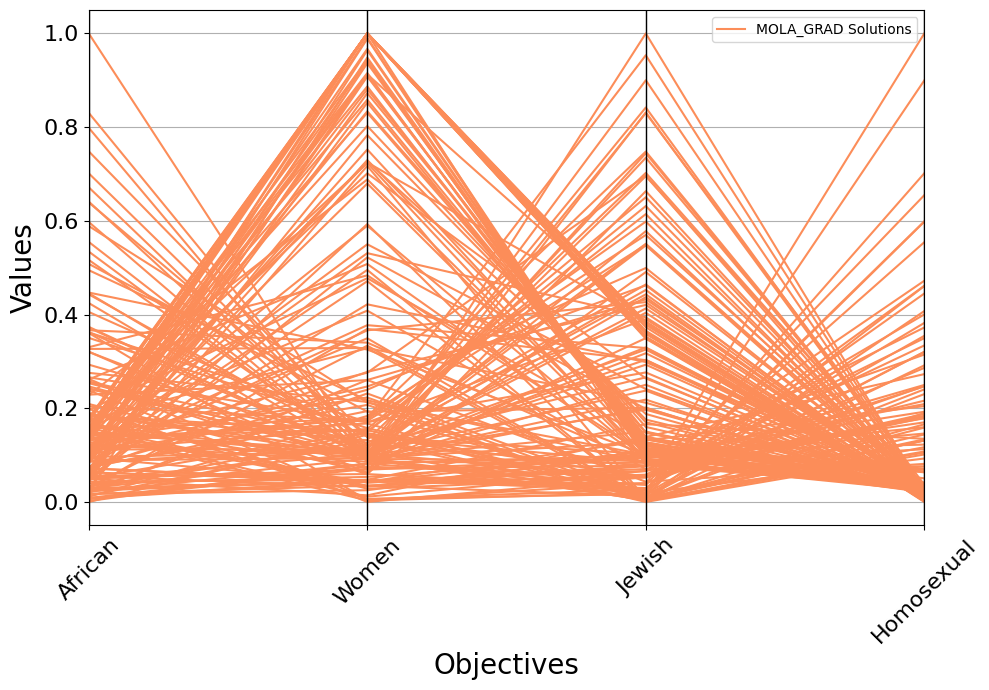

In [20]:
plot_frontier(f'{method}_grad', color='#fc8d59')

In [21]:
# save results
with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "wb") as f:
    dill.dump(results, f)

### Random Weight

In [22]:
method = 'random_weight'
machine_optimize(method=method)

### Non-dominated Solutions Analysis

In [23]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
rw_solutions = results['random_weight']['objectives']
nd_indices = NonDominatedSorting().do(rw_solutions, only_non_dominated_front=True)
rw_non_dominated_solutions = rw_solutions[nd_indices]

print(f'Number of non-dominated solutions with MOLA          : {len(results['mola']['objectives'])}')
print(f'Number of non-dominated solutions with MOLA GRAD     : {len(results['mola_grad']['objectives'])}')
print(f'Number of non-dominated solutions with RANDOM WEIGHT : {len(rw_non_dominated_solutions)}')

Number of non-dominated solutions with MOLA          : 380
Number of non-dominated solutions with MOLA GRAD     : 175
Number of non-dominated solutions with RANDOM WEIGHT : 214


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

<Figure size 3000x700 with 0 Axes>

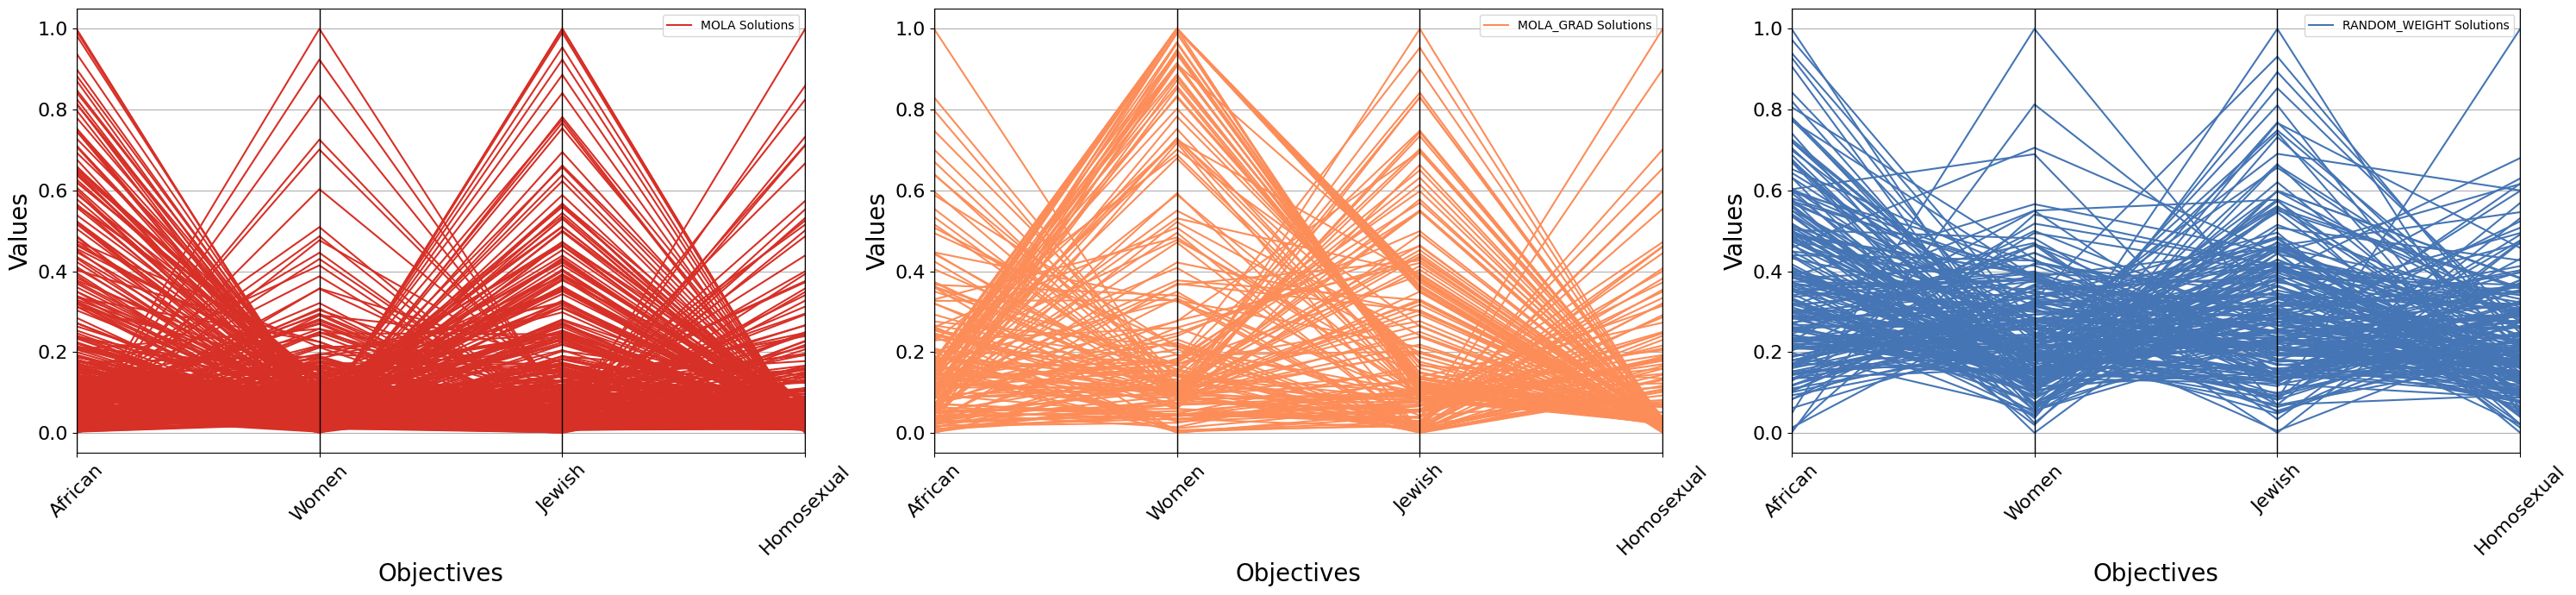

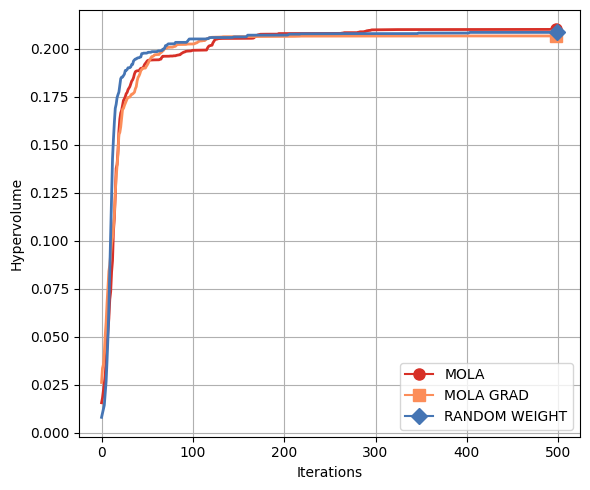

<Figure size 640x480 with 0 Axes>

In [24]:
pareto_dict = {
        method: res['objectives']
        for method, res in results.items()
        if 'objectives' in res
    }

pareto_dict['random_weight'] = rw_non_dominated_solutions

hypervolumes_dict = {
        method: res['hypervolume']
        for method, res in results.items()
        if 'hypervolume' in res
    }

plot_pareto(methods=pareto_dict,
            labels=objectives_names, 
            #title='Comparative Pareto Frontiers Across MOO Methods',
            #subset=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path=f'{PREFIX_SAVE_IMAGE}_methods.pdf'
            )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path=f'{PREFIX_SAVE_IMAGE}_hypervolume.pdf')

In [25]:
# save results
with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "wb") as f:
    dill.dump(results, f)

# get saved results
#with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "rb") as f:
#    outro_dict = pickle.load(f)

### Best Solution Criteria - Analysis with MOLA

In [26]:
from machinemoo.analysis.decision import select_lowest_median_solution, select_weighted_solution

In [27]:
mola = results['mola']

In [28]:
# Objective weights: higher values increase priority, balance defined by the weight vector
weights_vector = [0.2, 0.4, 0.2, 0.2]
solution_weighted = select_weighted_solution(mola['objectives'], mola['models'], weights_vector)
#print(solution_weighted)

<Figure size 1000x700 with 0 Axes>

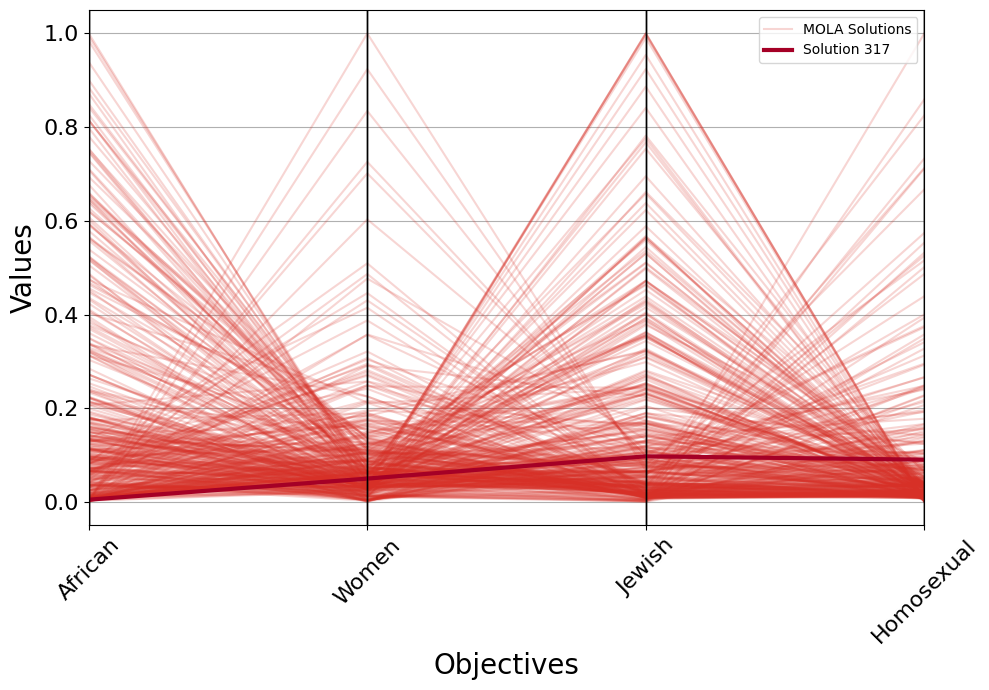

In [29]:
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=objectives_names, 
            #title=title,
            fontsize=15,
            figsize=(10,7),
            subset=[solution_weighted['objectives']],
            subset_label=f'Solution {solution_weighted['index']}',
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_weighted.pdf',
            alpha=0.2,
            s_factor=5,
            #color="grey"
            )

In [30]:
# Selects the solution with the lowest median across objectives, ignoring any objectives equal to 0.0
solution_median = select_lowest_median_solution(objectives=mola['objectives'], models=mola['models'])


# Selects the solution with the lowest median across objectives, ignoring any objectives equal to 0.0 
# and values above a predefined threshold.
# Thresholds can be set per objective using a dictionary: {objective_index: max_value}.
# Here, the 1st objective has a threshold of 6128.
solution_median_threshold = select_lowest_median_solution(
    mola['objectives'],
    models=mola['models'],
    objective_thresholds={0: 0.6128, 3:0.6}
)

In [31]:
#print(solution_median)
#print(solution_median_threshold)

In [43]:
type(solution_median['objectives'][0])

float

<Figure size 1000x700 with 0 Axes>

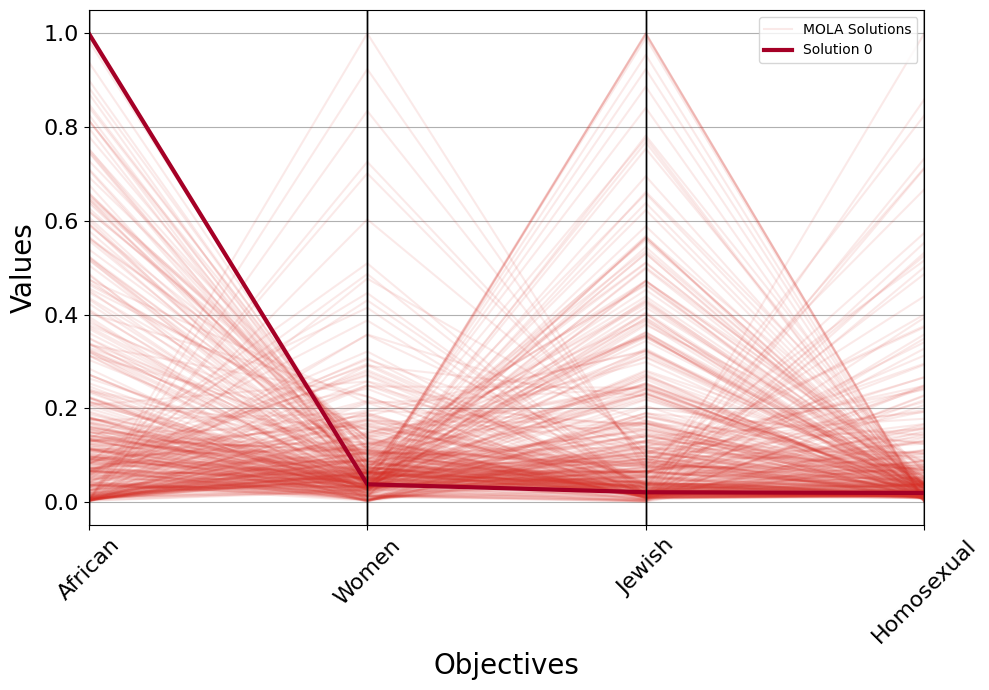

In [46]:
plot_pareto(methods={'mola': mola['objectives']},
            labels=objectives_names, 
            #title=title,
            fontsize=15,
            figsize=(10,7),
            subset=solution_median['objectives'],
            subset_label=f'Solution {solution_median['index']}',
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_median_t.pdf',
            alpha=0.1,
            s_factor=5,
            #color='grey',
            #y_threshold=0.6
            )

In [47]:
# Analysis three solutions together
subset = [
    solution_weighted['objectives'],
    solution_median['objectives'],
    solution_median_threshold['objectives']
]

labels = [
    f"Solution {solution_weighted['index']:<3} - Weighted",
    f"Solution {solution_median['index']:<3} - Median",
    f"Solution {solution_median_threshold['index']:<3} - Median Threshold"
]
markers = ['X', 'o', 's']

<Figure size 1000x700 with 0 Axes>

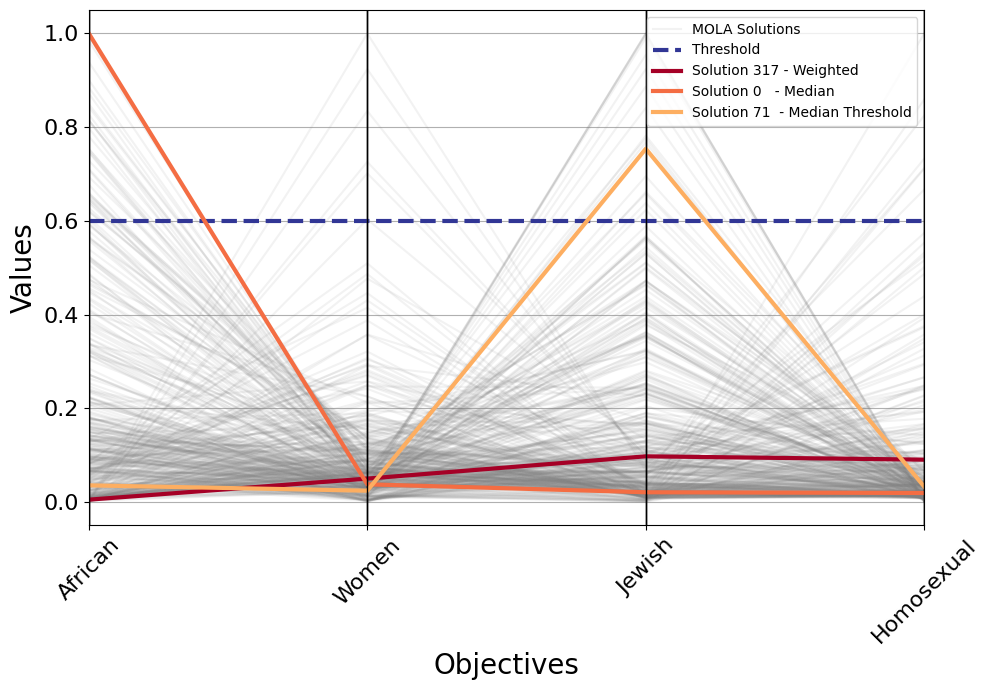

In [48]:
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=objectives_names, 
            # title=title,
            fontsize=20,
            figsize=(10,7),
            subset=subset,
            subset_label=labels,
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_decision.pdf',
            alpha=0.1,
            s_factor=5,
            subset_marker=markers,
            color='grey',
            y_threshold=0.6
            )

## EVALUATION

In [53]:
import torch
import torch.nn as nn
import numpy as np

def compute_val_losses(
    models,
    val_loader,
    task_names,
):
    """
    Calcula matriz de perdas de validação.
    
    Args:
        models: lista de modelos treinados
        val_loader: DataLoader do conjunto de validação
        objectives: lista de funções de loss (uma por objetivo)

    Returns:
        losses: tensor shape (n_models, n_objectives)
    """
    #device = next(models.parameters()).device
    n_obj = len(task_names)
    #objs = torch.zeros((n_models, n_obj), dtype=torch.float32)

    val_losses = []
    for model in models:
        total_batches = 0
        eval_losses = np.zeros(n_obj)
        model.eval()
        criterion = nn.CrossEntropyLoss()
        with torch.no_grad():
            for batch in val_loader:
                embeddings = batch["embedding"].to(device)
                logits_dict = model(embeddings)
                for i, task in enumerate(task_names):
                    labels = batch[task].to(device)
                    loss = criterion(logits_dict[task], labels)
                    eval_losses[i] += loss.item()
                total_batches += 1
        # objs /= len(self.train_dataloader)
        eval_losses /= total_batches
        val_losses.append(eval_losses)

    return np.array(val_losses)


In [50]:
val_dataloader = pp.get_dataloader(dataset['validation'], task_config)

In [56]:
val_losses = compute_val_losses(models=results['mola']['models'], val_loader=val_dataloader, task_names=objectives_names)

In [57]:
val_result = {}
for j, task in enumerate(objectives_names):
    best_model_idx = int(val_losses[:, j].argmin())
    best_loss = float(val_losses[:, j].min())
    val_result[task] = {
        "best_model": best_model_idx,
        "best_loss": best_loss,
    }

In [58]:
import pandas as pd
df = pd.DataFrame(val_result).T  # .T = transpose, tasks viram índice
print(df)


            best_model  best_loss
African           12.0   0.693073
Women            313.0   0.415405
Jewish           375.0   0.346235
Homosexual       290.0   0.316467


In [86]:
# Selects the solution with the lowest median across objectives, ignoring any objectives equal to 0.0
solution_median = select_lowest_median_solution(objectives=val_losses, models=results['mola']['models'])


# Selects the solution with the lowest median across objectives, ignoring any objectives equal to 0.0 
# and values above a predefined threshold.
# Thresholds can be set per objective using a dictionary: {objective_index: max_value}.
# Here, the 1st objective has a threshold of 0.4.
solution_median_threshold = select_lowest_median_solution(
    val_losses,
    models=results['mola']['models'],
    objective_thresholds={0: 0.4}
)

<Figure size 1000x700 with 0 Axes>

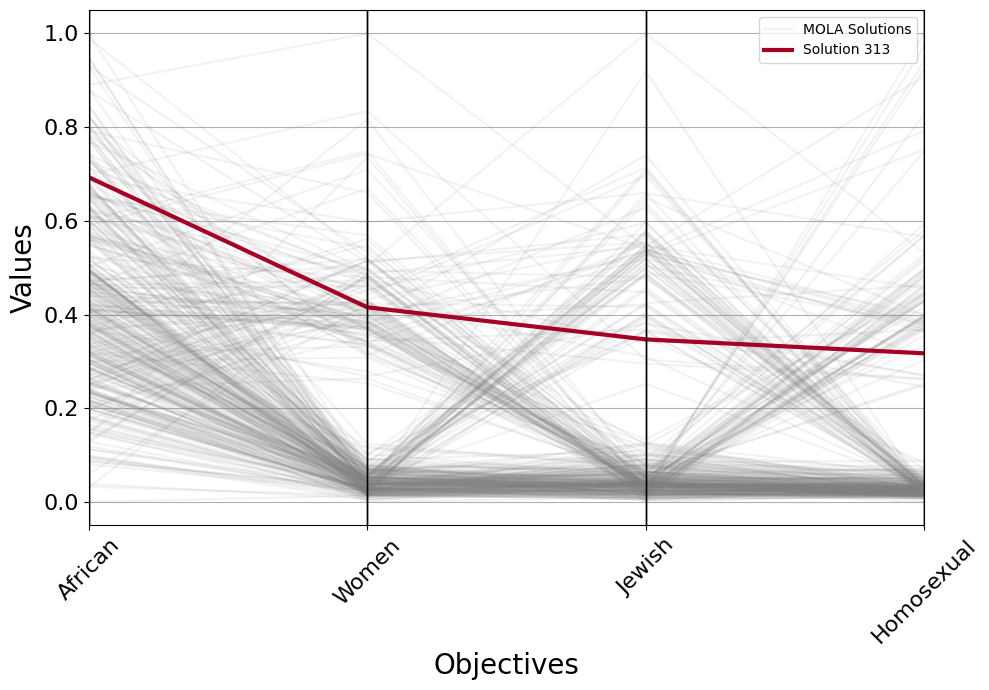

In [62]:
plot_pareto(methods={'mola': val_losses},
            labels=objectives_names, 
            #title=title,
            fontsize=15,
            figsize=(10,7),
            subset=solution_median['objectives'],
            subset_label=f'Solution {solution_median['index']}',
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_median.pdf',
            alpha=0.1,
            s_factor=5,
            color='grey'
            )

<Figure size 1000x700 with 0 Axes>

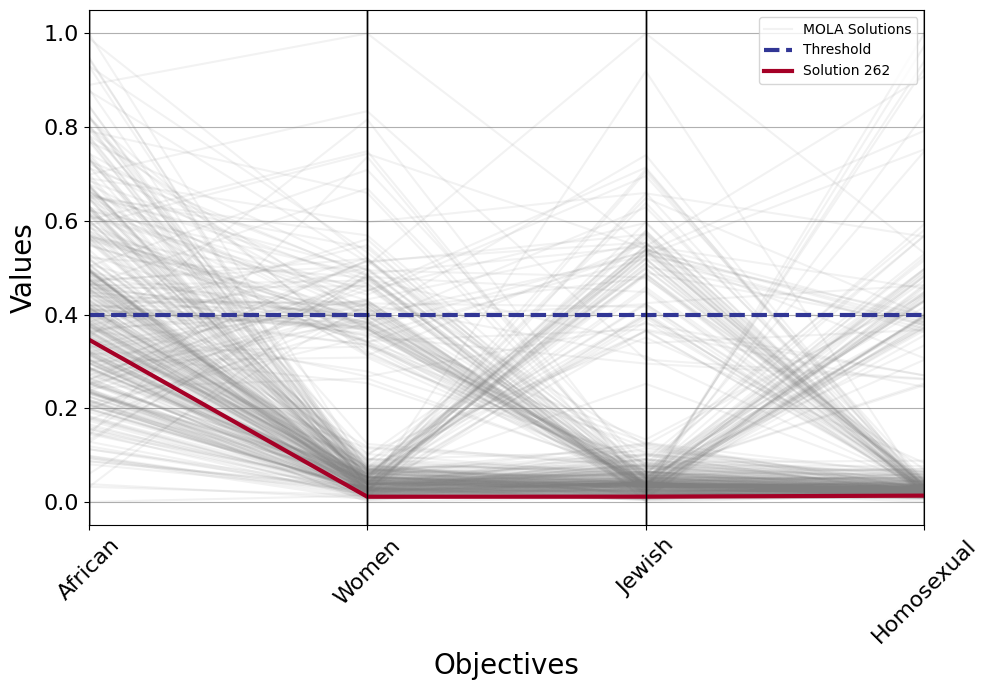

In [87]:
plot_pareto(methods={'mola': val_losses},
            labels=objectives_names, 
            # title=title,
            fontsize=20,
            figsize=(10,7),
            subset=solution_median_threshold['objectives'],
            subset_label=f'Solution {solution_median_threshold['index']}',
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_decision.pdf',
            alpha=0.1,
            s_factor=5,
            #subset_marker=markers,
            color='grey',
            y_threshold=0.4
            )

In [73]:
# Objective weights: higher values increase priority, balance defined by the weight vector
weights_vector = [0.4, 0.2, 0.2, 0.2]
solution_weighted = select_weighted_solution(val_losses, mola['models'], weights_vector)
print(solution_weighted)

{'index': 233, 'score': 0.04455288601185897, 'objectives': [0.087175513364277, 0.03285257495523847, 0.0038714551576895886, 0.011689373217812823], 'model': MultiTaskModel(
  (dropout): Dropout(p=0.3, inplace=False)
  (shared_fc): Linear(in_features=50, out_features=32, bias=True)
  (classifiers): ModuleDict(
    (African): Linear(in_features=32, out_features=2, bias=True)
    (Women): Linear(in_features=32, out_features=2, bias=True)
    (Jewish): Linear(in_features=32, out_features=2, bias=True)
    (Homosexual): Linear(in_features=32, out_features=2, bias=True)
  )
)}


<Figure size 1000x700 with 0 Axes>

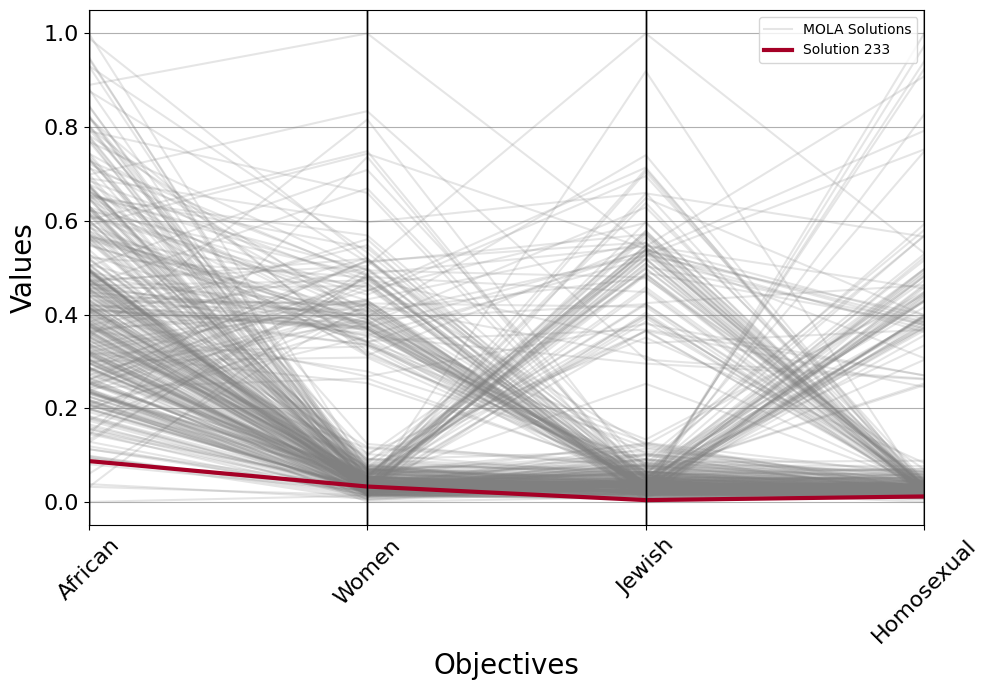

In [74]:
plot_pareto(methods={'mola': val_losses},
            labels=objectives_names, 
            #title=title,
            fontsize=15,
            figsize=(10,7),
            subset=solution_weighted['objectives'],
            subset_label=f'Solution {solution_weighted['index']}',
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_weighted.pdf',
            alpha=0.2,
            s_factor=5,
            color='grey'
            )